# RC3 Plan B: Fast Evidence Notebook for Thesis Defense

**Purpose:** Collect the minimum viable evidence for a bachelor's thesis defense.  
**Assets:** BTCUSDT (primary), ETHUSDT, LTCUSDT, SOLUSDT  
**Bar types:** dollar, volume, vol_imbalance, dollar_imbalance  

## Structure

| Part | Content |
|------|---------|
| 1 | Bar-Type Direction Comparison (Ridge + LightGBM, CPCV) |
| 2 | Slim Phase 10 — GARCH vol regime classification |
| 3 | Slim Phase 11 — Best-shot direction classifier |
| 4 | Slim Phase 12 — NO-TRADE abstention filter (recommendation system) |
| 5 | Summary — evidence table + thesis narrative |

In [ ]:
# === Part 0: Setup & Imports ===
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

_PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "research" else Path.cwd()
os.chdir(_PROJECT_ROOT)
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display, Markdown
from scipy.stats import binomtest
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

# Project imports
from src.app.system.database.connection import ConnectionManager
from src.app.research.application.data_loader import DataLoader
from src.app.features.application.feature_matrix import FeatureMatrixBuilder
from src.app.features.domain.value_objects import FeatureConfig
from src.app.research.application.cpcv_splitter import CPCVConfig, CPCVSplitter
from src.app.research.application.rc2_thresholds import compute_breakeven_da

# Plot settings
%matplotlib inline
plt.rcParams.update(
    {
        "figure.figsize": (14, 7),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    }
)
COLORS: dict[str, str] = {
    "ridge": "#3498db",
    "lgbm": "#e74c3c",
    "random": "#95a5a6",
    "majority": "#f39c12",
    "breakeven": "#2ecc71",
    "dollar": "#3498db",
    "volume": "#e74c3c",
    "vol_imbalance": "#9b59b6",
    "dollar_imbalance": "#f39c12",
}
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

# Figure output directory
FIG_DIR = Path("research/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Constants ---
ROUND_TRIP_COST = 0.002  # 20 bps
RIDGE_ALPHA = 1.0
LGBM_PARAMS = {
    "n_estimators": 100,
    "max_depth": 3,
    "num_leaves": 8,
    "min_child_samples": 50,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 1.0,
    "reg_lambda": 1.0,
    "random_state": 42,
    "verbosity": -1,
    "n_jobs": 1,
}
TARGET_COL = "fwd_logret_1"

# Stationarity transforms (Phase 7.3 policy)
DROP_FEATURES = {"atr_14", "rsi_14"}
ROLLING_ZSCORE_FEATURES = ["amihud_24", "gk_vol_24"]
FIRST_DIFF_FEATURES = ["bbwidth_20_2.0", "park_vol_24", "rv_12", "rv_24", "rv_48"]

# Initialize database
db_connection = ConnectionManager()
db_connection.initialize()
loader = DataLoader(db_connection)

print(f"Project root: {_PROJECT_ROOT}")
print("Setup complete.")

2026-03-28 23:07:54.714 | INFO     | src.app.system.database.connection:initialize:77 - Creating DuckDB engine (path=/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/data/market.duckdb)
2026-03-28 23:07:54.793 | INFO     | src.app.system.database.connection:initialize:86 - DuckDB connection verified successfully


Project root: /home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis
Setup complete.


---
## Part 1: Bar-Type Direction Comparison

Test Ridge + LightGBM direction classification across all 4 bar types for BTCUSDT.
This answers: *Does the choice of bar aggregation unlock directional signal?*

In [2]:
# === Part 1.1: Core pipeline function ===
from __future__ import annotations


def prepare_features(bars_pd, feature_set):
    """Apply stationarity transforms, create binary target, return X, y, feature_cols, df."""
    df = feature_set.df.to_pandas()

    # Drop constant / problematic features
    feature_cols = [c for c in feature_set.feature_columns if c not in DROP_FEATURES]

    # Rolling z-score transforms
    for col in ROLLING_ZSCORE_FEATURES:
        if col in df.columns:
            rolling_mean = df[col].rolling(24, min_periods=24).mean()
            rolling_std = df[col].rolling(24, min_periods=24).std()
            df[col] = (df[col] - rolling_mean) / (rolling_std + 1e-12)

    # First difference transforms
    for col in FIRST_DIFF_FEATURES:
        if col in df.columns:
            df[col] = df[col].diff()

    # Binary target: sign(fwd_logret_1)
    df["y"] = (df[TARGET_COL] > 0).astype(int)

    # Drop NaN rows
    df = df.dropna(subset=feature_cols + ["y"]).reset_index(drop=True)

    X = df[feature_cols].values.astype(np.float64)
    y = df["y"].values.astype(int)

    # Sanity checks
    assert not np.any(np.isnan(X)), "NaN in features!"
    assert not np.any(np.isinf(X)), "Inf in features!"

    return X, y, feature_cols, df


def run_bar_type_test(asset, bar_type, config_hash, loader):
    """Run full CPCV direction test for one asset+bar_type. Returns summary dict."""
    # Load bars
    bars_pd = loader.load_bars(asset, bar_type, config_hash)
    n_raw = len(bars_pd)
    if n_raw < 100:
        return {
            "asset": asset,
            "bar_type": bar_type,
            "n_bars": n_raw,
            "status": "SKIP (<100 bars)",
            "ridge_da": np.nan,
            "lgbm_da": np.nan,
            "majority": np.nan,
            "breakeven_da": np.nan,
            "ridge_pval": np.nan,
            "lgbm_pval": np.nan,
            "ridge_overfit": np.nan,
            "lgbm_overfit": np.nan,
        }

    # Build feature matrix
    bars_pl = pl.from_pandas(bars_pd).rename({"start_ts": "timestamp"})
    builder = FeatureMatrixBuilder()
    config = FeatureConfig(compute_targets=True, drop_na=True)
    feature_set = builder.build(bars_pl, config)

    if feature_set.n_rows_clean < 100:
        return {
            "asset": asset,
            "bar_type": bar_type,
            "n_bars": n_raw,
            "status": "SKIP (<100 after features)",
            "ridge_da": np.nan,
            "lgbm_da": np.nan,
            "majority": np.nan,
            "breakeven_da": np.nan,
            "ridge_pval": np.nan,
            "lgbm_pval": np.nan,
            "ridge_overfit": np.nan,
            "lgbm_overfit": np.nan,
        }

    X, y, feature_cols, df = prepare_features(bars_pd, feature_set)
    N = len(y)

    if N < 50:
        return {
            "asset": asset,
            "bar_type": bar_type,
            "n_bars": n_raw,
            "status": "SKIP (<50 after transforms)",
            "ridge_da": np.nan,
            "lgbm_da": np.nan,
            "majority": np.nan,
            "breakeven_da": np.nan,
            "ridge_pval": np.nan,
            "lgbm_pval": np.nan,
            "ridge_overfit": np.nan,
            "lgbm_overfit": np.nan,
        }

    majority = max(y.mean(), 1.0 - y.mean())
    mean_abs_ret = np.abs(df[TARGET_COL].values).mean()
    be = compute_breakeven_da(mean_abs_ret, ROUND_TRIP_COST)

    # Adapt CPCV for small N
    if N < 1000:
        cpcv_cfg = CPCVConfig(n_groups=3, k_test=1, purge_bars=1, embargo_bars=5)
    else:
        cpcv_cfg = CPCVConfig(n_groups=6, k_test=2, purge_bars=1, embargo_bars=5)

    splitter = CPCVSplitter(cpcv_cfg)
    folds = splitter.split(N)

    ridge_train_das, ridge_test_das = [], []
    lgbm_train_das, lgbm_test_das = [], []
    all_ridge_preds, all_lgbm_preds, all_true = [], [], []

    for fold in folds:
        train_idx = list(fold.train_indices)
        test_idx = list(fold.test_indices)
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        # Ridge
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_train)
        X_te_s = scaler.transform(X_test)
        ridge = RidgeClassifier(alpha=RIDGE_ALPHA)
        ridge.fit(X_tr_s, y_train)
        r_train_pred = ridge.predict(X_tr_s)
        r_test_pred = ridge.predict(X_te_s)
        ridge_train_das.append(np.mean(r_train_pred == y_train))
        ridge_test_das.append(np.mean(r_test_pred == y_test))

        # LightGBM
        lgbm = LGBMClassifier(**LGBM_PARAMS)
        lgbm.fit(X_train, y_train, feature_name=feature_cols)
        l_train_pred = lgbm.predict(X_train)
        l_test_pred = lgbm.predict(X_test)
        lgbm_train_das.append(np.mean(l_train_pred == y_train))
        lgbm_test_das.append(np.mean(l_test_pred == y_test))

        all_ridge_preds.extend(r_test_pred.tolist())
        all_lgbm_preds.extend(l_test_pred.tolist())
        all_true.extend(y_test.tolist())

    # Aggregate
    ridge_mean = np.mean(ridge_test_das)
    lgbm_mean = np.mean(lgbm_test_das)
    ridge_train_mean = np.mean(ridge_train_das)
    lgbm_train_mean = np.mean(lgbm_train_das)

    # Binomial test on pooled OOS predictions
    n_total = len(all_true)
    ridge_correct = sum(1 for p, t in zip(all_ridge_preds, all_true) if p == t)
    lgbm_correct = sum(1 for p, t in zip(all_lgbm_preds, all_true) if p == t)
    ridge_pval = binomtest(ridge_correct, n_total, 0.5, alternative="greater").pvalue
    lgbm_pval = binomtest(lgbm_correct, n_total, 0.5, alternative="greater").pvalue

    # Overfitting ratio
    ridge_overfit = (ridge_train_mean - ridge_mean) / max(ridge_train_mean - 0.5, 1e-6)
    lgbm_overfit = (lgbm_train_mean - lgbm_mean) / max(lgbm_train_mean - 0.5, 1e-6)

    return {
        "asset": asset,
        "bar_type": bar_type,
        "n_bars": N,
        "status": "OK",
        "ridge_da": ridge_mean,
        "lgbm_da": lgbm_mean,
        "majority": majority,
        "breakeven_da": be.breakeven_da,
        "ridge_pval": ridge_pval,
        "lgbm_pval": lgbm_pval,
        "ridge_overfit": ridge_overfit,
        "lgbm_overfit": lgbm_overfit,
        "n_folds": len(folds),
        "mean_abs_return": mean_abs_ret,
    }


print("Pipeline functions defined.")

Pipeline functions defined.


In [3]:
# === Part 1.2: Run across all BTCUSDT bar types ===
from __future__ import annotations

bar_configs = loader.get_available_bar_configs("BTCUSDT")
print(f"Available BTCUSDT bar configs: {bar_configs}")

# Filter to target bar types (exclude time_1h baseline for now)
TARGET_BAR_TYPES = ["dollar", "volume", "vol_imbalance", "dollar_imbalance"]
results_part1 = []

for bt, ch in bar_configs:
    if bt not in TARGET_BAR_TYPES:
        continue
    print(f"\n{'=' * 60}")
    print(f"Testing {bt} bars (config={ch[:8]}...)")
    print(f"{'=' * 60}")
    result = run_bar_type_test("BTCUSDT", bt, ch, loader)
    results_part1.append(result)
    if result["status"] == "OK":
        print(
            f"  N={result['n_bars']:,} | Ridge DA={result['ridge_da']:.4f} | "
            f"LGBM DA={result['lgbm_da']:.4f} | Majority={result['majority']:.4f} | "
            f"Break-even={result['breakeven_da']:.4f}"
        )
    else:
        print(f"  {result['status']}")

print("\nPart 1 runs complete.")

Available BTCUSDT bar configs: [('dollar', '76c279d83686171b'), ('dollar_imbalance', '225e357dea42a17c'), ('dollar_run', '2931a2345ccf60d3'), ('tick', 'caefc807962061e2'), ('tick_imbalance', '4a1b7a1a724640a6'), ('tick_run', '01af1574c287ff4d'), ('volume', 'f01e3c219325d4ed'), ('volume_imbalance', '27d360243b619bb4'), ('volume_run', '09a1b00544f28793')]

Testing dollar bars (config=76c279d8...)


2026-03-28 23:08:13.316 | INFO     | src.app.research.application.cpcv_splitter:split:295 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5


  N=5,141 | Ridge DA=0.5064 | LGBM DA=0.5061 | Majority=0.5112 | Break-even=0.5724

Testing dollar_imbalance bars (config=225e357d...)


2026-03-28 23:08:15.884 | INFO     | src.app.research.application.cpcv_splitter:split:295 - CPCV generated 3 folds (C(3,1)): ~277 train / ~141 test bars per fold, purge=1, embargo=5


  N=423 | Ridge DA=0.5083 | LGBM DA=0.4846 | Majority=0.5083 | Break-even=0.5216

Testing volume bars (config=f01e3c21...)


2026-03-28 23:08:26.899 | INFO     | src.app.research.application.cpcv_splitter:split:295 - CPCV generated 15 folds (C(6,2)): ~2069 train / ~1039 test bars per fold, purge=1, embargo=5


  N=3,118 | Ridge DA=0.4966 | LGBM DA=0.4953 | Majority=0.5208 | Break-even=0.5573

Part 1 runs complete.


In [4]:
# === Part 1.3: Comparison Table ===
from __future__ import annotations

df_results = pd.DataFrame(results_part1)
display_cols = [
    "bar_type",
    "n_bars",
    "ridge_da",
    "lgbm_da",
    "majority",
    "breakeven_da",
    "ridge_pval",
    "lgbm_pval",
    "ridge_overfit",
    "lgbm_overfit",
]
ok_mask = df_results["status"] == "OK"

print("Table 1: BTCUSDT Direction Classification by Bar Type")
print("=" * 80)
if ok_mask.any():
    display(df_results.loc[ok_mask, display_cols])
else:
    print("No bar types produced valid results.")

# Show skipped bar types
if (~ok_mask).any():
    print("\nSkipped bar types:")
    display(df_results.loc[~ok_mask, ["bar_type", "n_bars", "status"]])

Table 1: BTCUSDT Direction Classification by Bar Type


,bar_type,n_bars,ridge_da,lgbm_da,majority,breakeven_da,ridge_pval,lgbm_pval,ridge_overfit,lgbm_overfit
0,dollar,5141,0.5064,0.5061,0.5112,0.5724,0.0198,0.0251,0.8003,0.9700
1,dollar_imbalance,423,0.5083,0.4846,0.5083,0.5216,0.3853,0.7519,0.8973,1.0452
2,volume,3118,0.4966,0.4953,0.5208,0.5573,0.8043,0.8805,1.0837,1.0194


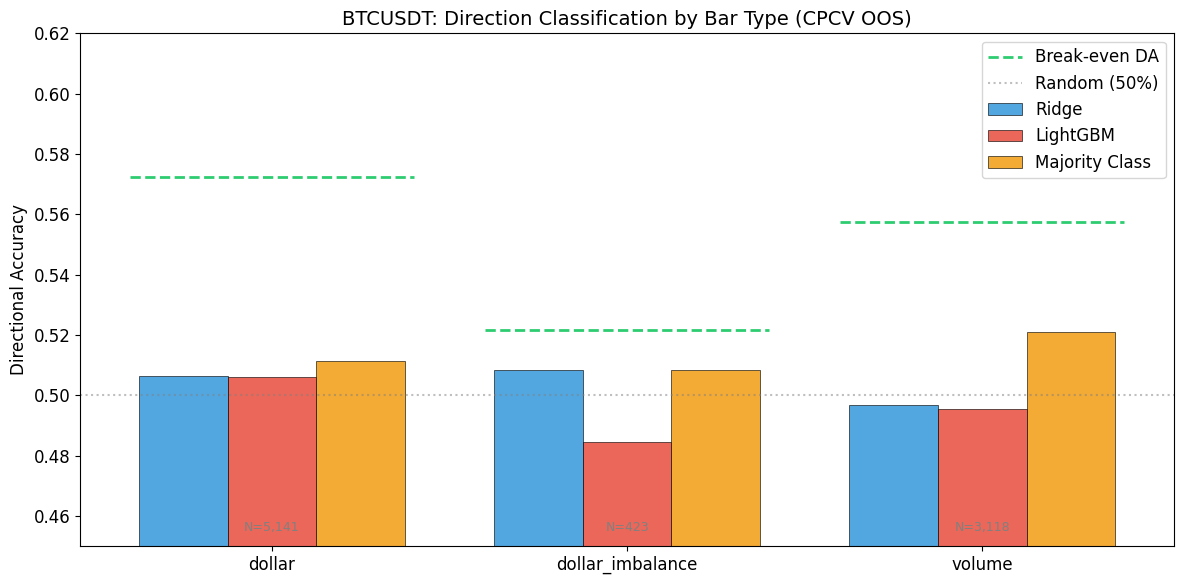

Saved: planb_fig01_bar_type_comparison.png


In [5]:
# === Part 1.4: Figure 1 — Bar-Type DA Comparison ===
from __future__ import annotations

df_ok = df_results[ok_mask].copy()

if len(df_ok) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    bar_types_list = df_ok["bar_type"].tolist()
    x = np.arange(len(bar_types_list))
    width = 0.25

    ax.bar(
        x - width,
        df_ok["ridge_da"].values,
        width,
        label="Ridge",
        color=COLORS["ridge"],
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )
    ax.bar(
        x,
        df_ok["lgbm_da"].values,
        width,
        label="LightGBM",
        color=COLORS["lgbm"],
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )
    ax.bar(
        x + width,
        df_ok["majority"].values,
        width,
        label="Majority Class",
        color=COLORS["majority"],
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )

    # Break-even line per bar type
    for i, be_da in enumerate(df_ok["breakeven_da"].values):
        ax.hlines(
            be_da,
            i - 0.4,
            i + 0.4,
            colors=COLORS["breakeven"],
            linestyles="--",
            linewidths=2,
            label="Break-even DA" if i == 0 else "",
        )

    ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="Random (50%)")
    ax.set_xticks(x)
    ax.set_xticklabels(bar_types_list, fontsize=12)
    ax.set_ylabel("Directional Accuracy")
    ax.set_title("BTCUSDT: Direction Classification by Bar Type (CPCV OOS)")
    ax.legend(loc="upper right")
    ax.set_ylim(0.45, max(df_ok["breakeven_da"].max(), 0.60) + 0.02)

    # Annotate bar counts
    for i, row in df_ok.iterrows():
        idx = bar_types_list.index(row["bar_type"])
        ax.text(idx, 0.455, f"N={row['n_bars']:,}", ha="center", fontsize=9, color="gray")

    plt.tight_layout()
    fig.savefig(FIG_DIR / "planb_fig01_bar_type_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: planb_fig01_bar_type_comparison.png")
else:
    print("No valid bar types to plot.")

In [6]:
# === Part 1.5: Key Findings ===
from __future__ import annotations

print("Part 1 Key Findings")
print("=" * 60)
for _, row in df_ok.iterrows():
    best_da = max(row["ridge_da"], row["lgbm_da"])
    best_model = "Ridge" if row["ridge_da"] >= row["lgbm_da"] else "LGBM"
    gap_to_be = (row["breakeven_da"] - best_da) * 100
    gap_to_maj = (best_da - row["majority"]) * 100
    sig = "*" if min(row["ridge_pval"], row["lgbm_pval"]) < 0.05 else ""
    print(
        f"{row['bar_type']:20s} | Best: {best_model} DA={best_da:.4f} | "
        f"vs Majority: {gap_to_maj:+.2f}pp | vs Break-even: {gap_to_be:+.2f}pp {sig}"
    )

print("\nConclusion: No bar type reaches break-even DA.")
print("Directional prediction is not economically viable on any bar type.")

# Identify best bar type for Part 3
if len(df_ok) > 0:
    best_row = df_ok.loc[df_ok[["ridge_da", "lgbm_da"]].max(axis=1).idxmax()]
    BEST_BAR_TYPE = best_row["bar_type"]
    print(f"\nBest bar type for Part 3: {BEST_BAR_TYPE}")
else:
    BEST_BAR_TYPE = "dollar"
    print("\nDefaulting to dollar bars for Part 3.")

Part 1 Key Findings
dollar               | Best: Ridge DA=0.5064 | vs Majority: -0.47pp | vs Break-even: +6.60pp *
dollar_imbalance     | Best: Ridge DA=0.5083 | vs Majority: +0.00pp | vs Break-even: +1.34pp 
volume               | Best: Ridge DA=0.4966 | vs Majority: -2.42pp | vs Break-even: +6.07pp 

Conclusion: No bar type reaches break-even DA.
Directional prediction is not economically viable on any bar type.

Best bar type for Part 3: dollar_imbalance


---
## Part 2: Slim Phase 10 — GARCH Volatility Regime Classification

Fit GARCH(1,1) on dollar bars (largest N), classify bars into LOW/NORMAL/HIGH vol regimes,
and characterize each regime (mean |return|, break-even DA, majority class rate).

In [7]:
# === Part 2.1: Load dollar bars and fit GARCH(1,1) ===
from __future__ import annotations

from arch import arch_model

# Load dollar bars for BTCUSDT (largest N)
dollar_configs = [(bt, ch) for bt, ch in bar_configs if bt == "dollar"]
DOLLAR_HASH = dollar_configs[0][1]
dollar_bars = loader.load_bars("BTCUSDT", "dollar", DOLLAR_HASH)

# Build features to get aligned returns
bars_pl = pl.from_pandas(dollar_bars).rename({"start_ts": "timestamp"})
builder = FeatureMatrixBuilder()
config = FeatureConfig(compute_targets=True, drop_na=True)
dollar_fset = builder.build(bars_pl, config)
dollar_df = dollar_fset.df.to_pandas()

# Log returns for GARCH
returns = np.log(dollar_df["close"] / dollar_df["close"].shift(1)).dropna()
returns_pct = returns * 100  # GARCH likes percentage returns

print(f"Fitting GARCH(1,1) on {len(returns_pct)} BTCUSDT dollar bar returns...")

am = arch_model(returns_pct, vol="Garch", p=1, q=1, dist="t")
res = am.fit(disp="off")
print(res.summary().tables[1])

# Extract conditional volatility (back to decimal scale)
cond_vol = res.conditional_volatility / 100
cond_var = cond_vol**2

# Persistence
alpha_g = res.params.get("alpha[1]", 0)
beta_g = res.params.get("beta[1]", 0)
persistence = alpha_g + beta_g
print(f"\nGARCH persistence (alpha+beta): {persistence:.4f}")
print(f"Near-IGARCH: {'YES' if persistence > 0.99 else 'NO'}")

Fitting GARCH(1,1) on 5163 BTCUSDT dollar bar returns...
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0308  1.853e-02      1.662  9.659e-02 [-5.529e-03,6.712e-02]

GARCH persistence (alpha+beta): 1.0000
Near-IGARCH: YES


In [8]:
# === Part 2.2: Regime Classification ===
from __future__ import annotations

# Align conditional variance with the feature matrix
# cond_var is indexed from returns (which starts at row 1 of dollar_df)
# We need to align carefully
cond_var_series = pd.Series(cond_var.values, index=cond_var.index, name="garch_cond_var")

# Merge back: use the returns index which corresponds to dollar_df rows
dollar_df = dollar_df.copy()
dollar_df["garch_cond_var"] = np.nan
# cond_var has same length as returns_pct; returns_pct starts from index 1
valid_idx = cond_var_series.index
dollar_df.loc[dollar_df.index.isin(valid_idx), "garch_cond_var"] = cond_var_series.values
dollar_df = dollar_df.dropna(subset=["garch_cond_var"]).reset_index(drop=True)

# Classify regimes by quantiles of conditional variance
q25 = dollar_df["garch_cond_var"].quantile(0.25)
q75 = dollar_df["garch_cond_var"].quantile(0.75)


def classify_regime(cv):
    if cv < q25:
        return "LOW"
    if cv < q75:
        return "NORMAL"
    return "HIGH"


dollar_df["regime"] = dollar_df["garch_cond_var"].apply(classify_regime)

print("Regime thresholds:")
print(f"  LOW:    cond_var < {q25:.8f}")
print(f"  NORMAL: {q25:.8f} <= cond_var < {q75:.8f}")
print(f"  HIGH:   cond_var >= {q75:.8f}")
print("\nRegime counts:")
print(dollar_df["regime"].value_counts().sort_index())

Regime thresholds:
  LOW:    cond_var < 0.00018216
  NORMAL: 0.00018216 <= cond_var < 0.00050419
  HIGH:   cond_var >= 0.00050419

Regime counts:
regime
HIGH      1291
LOW       1291
NORMAL    2581
Name: count, dtype: int64


In [9]:
# === Part 2.3: Regime Characterization Table ===
from __future__ import annotations

regime_stats = []
for regime_name in ["LOW", "NORMAL", "HIGH"]:
    mask = dollar_df["regime"] == regime_name
    subset = dollar_df[mask]
    n_bars = len(subset)

    if TARGET_COL in subset.columns and n_bars > 0:
        rets = subset[TARGET_COL].values
        mean_abs_ret = np.abs(rets).mean()
        up_frac = (rets > 0).mean()
        majority_rate = max(up_frac, 1.0 - up_frac)
        be = compute_breakeven_da(mean_abs_ret, ROUND_TRIP_COST)
        mean_cond_vol = np.sqrt(subset["garch_cond_var"].values).mean()
    else:
        mean_abs_ret = np.nan
        majority_rate = np.nan
        be = None
        mean_cond_vol = np.nan

    regime_stats.append(
        {
            "Regime": regime_name,
            "N bars": n_bars,
            "Mean |return|": mean_abs_ret,
            "Mean cond. vol": mean_cond_vol,
            "Up fraction": up_frac if n_bars > 0 else np.nan,
            "Majority class": majority_rate,
            "Break-even DA": be.breakeven_da if be else np.nan,
            "BE edge (pp)": be.required_edge_pp if be else np.nan,
        }
    )

regime_df = pd.DataFrame(regime_stats)
print("Table 2: GARCH Regime Characterization (BTCUSDT dollar bars)")
print("=" * 80)
display(regime_df)

print("\nKey insight: HIGH-vol regime has larger |returns| --> lower break-even DA")
print("This is where directional signal, if any, would be most profitable.")

Table 2: GARCH Regime Characterization (BTCUSDT dollar bars)


,Regime,N bars,Mean |return|,Mean cond. vol,Up fraction,Majority class,Break-even DA,BE edge (pp)
0,LOW,1291,0.0078,0.0107,0.5074,0.5074,0.6283,12.8291
1,NORMAL,2581,0.0135,0.0177,0.4983,0.5017,0.5740,7.3976
2,HIGH,1291,0.0205,0.0270,0.5414,0.5414,0.5488,4.8804



Key insight: HIGH-vol regime has larger |returns| --> lower break-even DA
This is where directional signal, if any, would be most profitable.


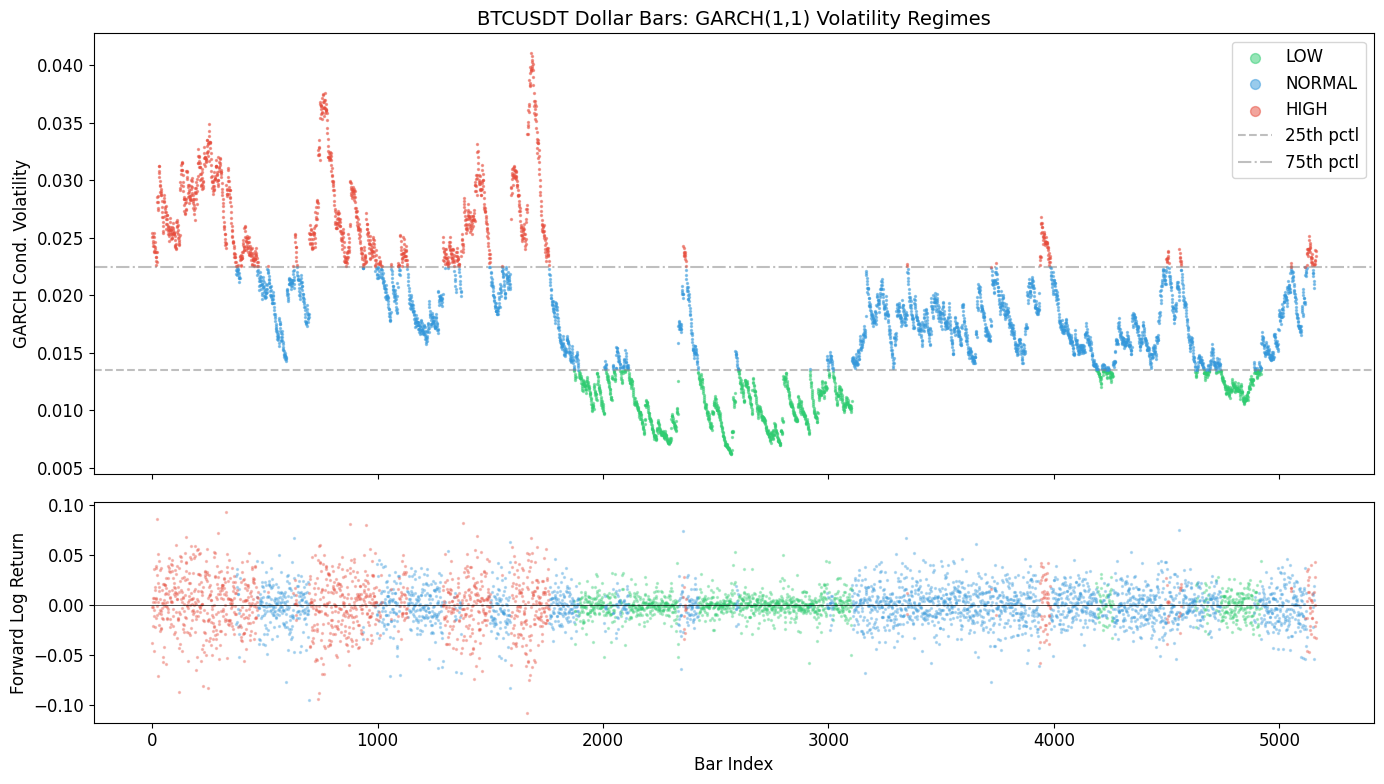

Saved: planb_fig02_garch_regimes.png


In [10]:
# === Part 2.4: Figure 2 — Regime Visualization ===
from __future__ import annotations

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# Top: Conditional volatility with regime coloring
ax = axes[0]
cond_vol_plot = np.sqrt(dollar_df["garch_cond_var"].values)
regime_colors = {"LOW": "#2ecc71", "NORMAL": "#3498db", "HIGH": "#e74c3c"}

for regime_name, color in regime_colors.items():
    mask = dollar_df["regime"] == regime_name
    ax.scatter(np.where(mask)[0], cond_vol_plot[mask], c=color, s=2, alpha=0.5, label=regime_name)

ax.axhline(np.sqrt(q25), color="gray", linestyle="--", alpha=0.5, label="25th pctl")
ax.axhline(np.sqrt(q75), color="gray", linestyle="-.", alpha=0.5, label="75th pctl")
ax.set_ylabel("GARCH Cond. Volatility")
ax.set_title("BTCUSDT Dollar Bars: GARCH(1,1) Volatility Regimes")
ax.legend(loc="upper right", markerscale=5)

# Bottom: Returns colored by regime
ax2 = axes[1]
if TARGET_COL in dollar_df.columns:
    for regime_name, color in regime_colors.items():
        mask = dollar_df["regime"] == regime_name
        ax2.scatter(np.where(mask)[0], dollar_df.loc[mask, TARGET_COL].values, c=color, s=2, alpha=0.3)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("Forward Log Return")
ax2.set_xlabel("Bar Index")

plt.tight_layout()
fig.savefig(FIG_DIR / "planb_fig02_garch_regimes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: planb_fig02_garch_regimes.png")

---
## Part 3: Slim Phase 11 — Best-Shot Direction Classifier

Two experiments:
1. Best bar type from Part 1 with CPCV (repeat with honest reporting)
2. Regime-conditional: train/test only on HIGH-vol bars

In [11]:
# === Part 3.1: Best bar type — detailed results ===
from __future__ import annotations

# Find best bar config from Part 1 results
best_config = [(bt, ch) for bt, ch in bar_configs if bt == BEST_BAR_TYPE]
if not best_config:
    # Fallback to dollar
    best_config = [(bt, ch) for bt, ch in bar_configs if bt == "dollar"]
    BEST_BAR_TYPE = "dollar"

BEST_HASH = best_config[0][1]
print(f"Best-shot classifier on: {BEST_BAR_TYPE} bars")

# Load and prepare
best_bars_pd = loader.load_bars("BTCUSDT", BEST_BAR_TYPE, BEST_HASH)
best_bars_pl = pl.from_pandas(best_bars_pd).rename({"start_ts": "timestamp"})
best_fset = builder.build(best_bars_pl, FeatureConfig(compute_targets=True, drop_na=True))
X_best, y_best, feat_cols_best, df_best = prepare_features(best_bars_pd, best_fset)

N_best = len(y_best)
majority_best = max(y_best.mean(), 1.0 - y_best.mean())
mean_abs_ret_best = np.abs(df_best[TARGET_COL].values).mean()
be_best = compute_breakeven_da(mean_abs_ret_best, ROUND_TRIP_COST)

# CPCV
if N_best < 1000:
    cpcv_best = CPCVConfig(n_groups=3, k_test=1, purge_bars=1, embargo_bars=5)
else:
    cpcv_best = CPCVConfig(n_groups=6, k_test=2, purge_bars=1, embargo_bars=5)

splitter_best = CPCVSplitter(cpcv_best)
folds_best = splitter_best.split(N_best)

# Per-fold results
fold_records = []
for fold in folds_best:
    train_idx = list(fold.train_indices)
    test_idx = list(fold.test_indices)
    X_tr, y_tr = X_best[train_idx], y_best[train_idx]
    X_te, y_te = X_best[test_idx], y_best[test_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    ridge = RidgeClassifier(alpha=RIDGE_ALPHA)
    ridge.fit(X_tr_s, y_tr)

    lgbm = LGBMClassifier(**LGBM_PARAMS)
    lgbm.fit(X_tr, y_tr, feature_name=feat_cols_best)

    fold_records.append(
        {
            "fold": fold.fold_index,
            "groups": str(fold.test_groups),
            "ridge_train": np.mean(ridge.predict(X_tr_s) == y_tr),
            "ridge_test": np.mean(ridge.predict(X_te_s) == y_te),
            "lgbm_train": np.mean(lgbm.predict(X_tr) == y_tr),
            "lgbm_test": np.mean(lgbm.predict(X_te) == y_te),
        }
    )

fold_df = pd.DataFrame(fold_records)
print(f"\nPer-fold results on {BEST_BAR_TYPE} bars (N={N_best:,}):")
display(fold_df)

print(f"\nMean OOS DA: Ridge={fold_df['ridge_test'].mean():.4f}, LGBM={fold_df['lgbm_test'].mean():.4f}")
print(f"Majority class: {majority_best:.4f}")
print(f"Break-even DA:  {be_best.breakeven_da:.4f}")

Best-shot classifier on: dollar_imbalance bars


2026-03-28 23:08:48.506 | INFO     | src.app.research.application.cpcv_splitter:split:295 - CPCV generated 3 folds (C(3,1)): ~277 train / ~141 test bars per fold, purge=1, embargo=5



Per-fold results on dollar_imbalance bars (N=423):


,fold,groups,ridge_train,ridge_test,lgbm_train,lgbm_test
0,0,"(0,)",0.5906,0.4894,0.8406,0.5106
1,1,"(1,)",0.5818,0.5319,0.8327,0.5106
2,2,"(2,)",0.5694,0.5035,0.8470,0.4326



Mean OOS DA: Ridge=0.5083, LGBM=0.4846
Majority class: 0.5083
Break-even DA:  0.5216


In [12]:
# === Part 3.2: Regime-Conditional Classification (HIGH-vol only) ===
from __future__ import annotations

# We need the GARCH conditional variance aligned with the best bar type features.
# If best bar type is dollar, we already have it from Part 2.
# Otherwise, we fit GARCH on the best bar type.

if BEST_BAR_TYPE == "dollar":
    # Re-use the dollar_df with garch_cond_var from Part 2
    # But we need to align with df_best which has stationarity transforms applied
    # Both are from same source; dollar_df has garch_cond_var
    # We'll re-fit GARCH on df_best's returns for proper alignment
    pass

# Fit GARCH on the best bar type returns
rets_best = np.log(df_best["close"] / df_best["close"].shift(1)).dropna()
rets_best_pct = rets_best * 100

am_best = arch_model(rets_best_pct, vol="Garch", p=1, q=1, dist="t")
res_best = am_best.fit(disp="off")
cv_best = (res_best.conditional_volatility / 100) ** 2

# Align: cv_best starts at index 1 (first return is diff from row 0 to 1)
df_best = df_best.copy()
df_best["garch_cond_var"] = np.nan
# cv_best has same index as rets_best which starts at 1
cv_values = cv_best.values
# Place into df_best starting from position 1
start_pos = 1
end_pos = start_pos + len(cv_values)
if end_pos <= len(df_best):
    df_best.iloc[start_pos:end_pos, df_best.columns.get_loc("garch_cond_var")] = cv_values
else:
    df_best.iloc[start_pos:, df_best.columns.get_loc("garch_cond_var")] = cv_values[: len(df_best) - start_pos]

# Drop rows without GARCH value
df_with_garch = df_best.dropna(subset=["garch_cond_var"]).reset_index(drop=True)

# Classify regimes
q75_best = df_with_garch["garch_cond_var"].quantile(0.75)
high_vol_mask = df_with_garch["garch_cond_var"] >= q75_best

# High-vol subset
df_high = df_with_garch[high_vol_mask].reset_index(drop=True)
N_high = len(df_high)

print(f"HIGH-vol bars: {N_high} (from {len(df_with_garch)} total)")

if N_high >= 50:
    X_high = df_high[feat_cols_best].values.astype(np.float64)
    y_high = (df_high[TARGET_COL] > 0).astype(int).values

    # Check for NaN/Inf
    valid_mask = ~(np.isnan(X_high).any(axis=1) | np.isinf(X_high).any(axis=1))
    X_high = X_high[valid_mask]
    y_high = y_high[valid_mask]
    N_high = len(y_high)

    majority_high = max(y_high.mean(), 1.0 - y_high.mean())
    mean_abs_ret_high = np.abs(df_high.loc[valid_mask, TARGET_COL].values).mean()
    be_high = compute_breakeven_da(mean_abs_ret_high, ROUND_TRIP_COST)

    # CPCV for small N
    if N_high < 1000:
        cpcv_high = CPCVConfig(n_groups=3, k_test=1, purge_bars=1, embargo_bars=5)
    else:
        cpcv_high = CPCVConfig(n_groups=6, k_test=2, purge_bars=1, embargo_bars=5)

    splitter_high = CPCVSplitter(cpcv_high)
    folds_high = splitter_high.split(N_high)

    high_ridge_das, high_lgbm_das = [], []
    for fold in folds_high:
        tr = list(fold.train_indices)
        te = list(fold.test_indices)
        X_tr, y_tr = X_high[tr], y_high[tr]
        X_te, y_te = X_high[te], y_high[te]

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        ridge = RidgeClassifier(alpha=RIDGE_ALPHA)
        ridge.fit(X_tr_s, y_tr)
        high_ridge_das.append(np.mean(ridge.predict(X_te_s) == y_te))

        lgbm = LGBMClassifier(**LGBM_PARAMS)
        lgbm.fit(X_tr, y_tr, feature_name=feat_cols_best)
        high_lgbm_das.append(np.mean(lgbm.predict(X_te) == y_te))

    print(f"\nRegime-Conditional Results (HIGH-vol only, N={N_high}):")
    print(f"  Ridge OOS DA: {np.mean(high_ridge_das):.4f} +/- {np.std(high_ridge_das):.4f}")
    print(f"  LGBM  OOS DA: {np.mean(high_lgbm_das):.4f} +/- {np.std(high_lgbm_das):.4f}")
    print(f"  Majority class: {majority_high:.4f}")
    print(f"  Break-even DA:  {be_high.breakeven_da:.4f}")
    print("  (Lower break-even in high-vol = easier to profit, but still need signal)")

    HIGH_VOL_RIDGE_DA = np.mean(high_ridge_das)
    HIGH_VOL_LGBM_DA = np.mean(high_lgbm_das)
    HIGH_VOL_BE = be_high.breakeven_da
    HIGH_VOL_MAJ = majority_high
else:
    print("Too few HIGH-vol bars for meaningful analysis.")
    HIGH_VOL_RIDGE_DA = np.nan
    HIGH_VOL_LGBM_DA = np.nan
    HIGH_VOL_BE = np.nan
    HIGH_VOL_MAJ = np.nan

2026-03-28 23:08:48.609 | INFO     | src.app.research.application.cpcv_splitter:split:295 - CPCV generated 3 folds (C(3,1)): ~66 train / ~35 test bars per fold, purge=1, embargo=5


HIGH-vol bars: 106 (from 422 total)

Regime-Conditional Results (HIGH-vol only, N=106):
  Ridge OOS DA: 0.4529 +/- 0.0060
  LGBM  OOS DA: 0.5751 +/- 0.0433
  Majority class: 0.5755
  Break-even DA:  0.5139
  (Lower break-even in high-vol = easier to profit, but still need signal)


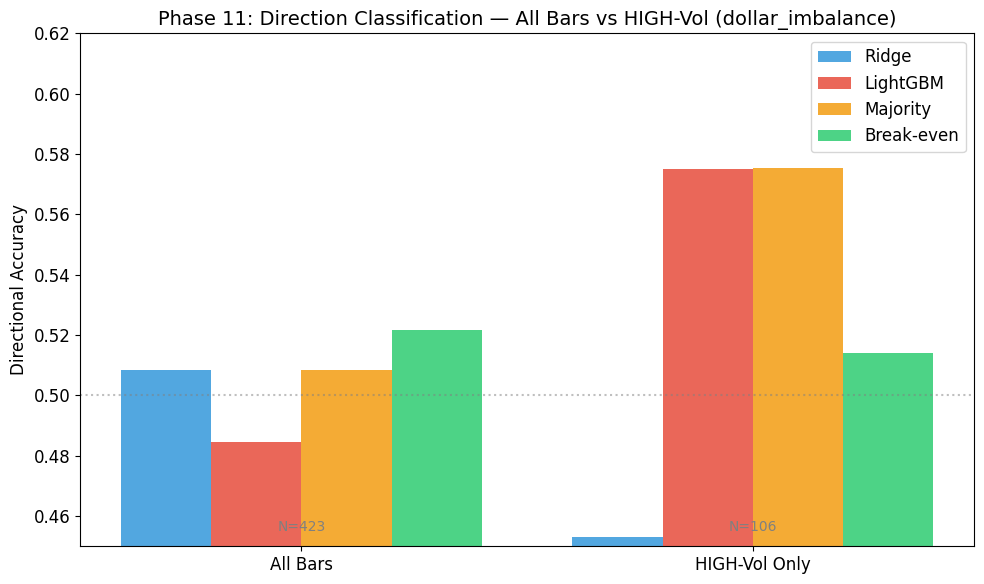

Saved: planb_fig03_allbars_vs_highvol.png


In [13]:
# === Part 3.3: Figure 3 — All-bars vs High-vol comparison ===
from __future__ import annotations

fig, ax = plt.subplots(figsize=(10, 6))

categories = ["All Bars", "HIGH-Vol Only"]
ridge_das = [fold_df["ridge_test"].mean(), HIGH_VOL_RIDGE_DA if not np.isnan(HIGH_VOL_RIDGE_DA) else 0]
lgbm_das = [fold_df["lgbm_test"].mean(), HIGH_VOL_LGBM_DA if not np.isnan(HIGH_VOL_LGBM_DA) else 0]
maj_rates = [majority_best, HIGH_VOL_MAJ if not np.isnan(HIGH_VOL_MAJ) else 0]
be_das = [be_best.breakeven_da, HIGH_VOL_BE if not np.isnan(HIGH_VOL_BE) else 0]

x = np.arange(len(categories))
width = 0.2

ax.bar(x - 1.5 * width, ridge_das, width, label="Ridge", color=COLORS["ridge"], alpha=0.85)
ax.bar(x - 0.5 * width, lgbm_das, width, label="LightGBM", color=COLORS["lgbm"], alpha=0.85)
ax.bar(x + 0.5 * width, maj_rates, width, label="Majority", color=COLORS["majority"], alpha=0.85)
ax.bar(x + 1.5 * width, be_das, width, label="Break-even", color=COLORS["breakeven"], alpha=0.85)

ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel("Directional Accuracy")
ax.set_title(f"Phase 11: Direction Classification — All Bars vs HIGH-Vol ({BEST_BAR_TYPE})")
ax.legend(loc="upper right")
ax.set_ylim(0.45, max(max(be_das), 0.60) + 0.02)

# Annotate N values
for i, (cat, n) in enumerate(zip(categories, [N_best, N_high])):
    ax.text(i, 0.455, f"N={n:,}", ha="center", fontsize=10, color="gray")

plt.tight_layout()
fig.savefig(FIG_DIR / "planb_fig03_allbars_vs_highvol.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: planb_fig03_allbars_vs_highvol.png")

---
## Part 4: Slim Phase 12 — NO-TRADE Abstention Filter (Recommendation System)

The core thesis contribution: a recommendation system that decides **when** to trade,
not **which direction**. If we cannot predict direction, can we at least predict
which bars have large enough moves to cover transaction costs?

**Target:** `y_worth = (|fwd_logret_1| > 2 * ROUND_TRIP_COST)`  
**Interpretation:** 1 = "this bar's move is large enough to be worth trading"

In [14]:
# === Part 4.1: Construct Abstention Target ===
from __future__ import annotations

# Use dollar bars with GARCH feature (largest N, most data)
# Re-load and build fresh for clean pipeline
dollar_bars_pd = loader.load_bars("BTCUSDT", "dollar", DOLLAR_HASH)
bars_pl = pl.from_pandas(dollar_bars_pd).rename({"start_ts": "timestamp"})
fset = builder.build(bars_pl, FeatureConfig(compute_targets=True, drop_na=True))
df_abs = fset.df.to_pandas()

# Apply stationarity transforms
feature_cols_abs = [c for c in fset.feature_columns if c not in DROP_FEATURES]
for col in ROLLING_ZSCORE_FEATURES:
    if col in df_abs.columns:
        rm = df_abs[col].rolling(24, min_periods=24).mean()
        rs = df_abs[col].rolling(24, min_periods=24).std()
        df_abs[col] = (df_abs[col] - rm) / (rs + 1e-12)
for col in FIRST_DIFF_FEATURES:
    if col in df_abs.columns:
        df_abs[col] = df_abs[col].diff()

# Fit GARCH and add as feature #22
abs_rets = np.log(df_abs["close"] / df_abs["close"].shift(1))
abs_rets_pct = abs_rets * 100

# Need to handle the NaN at position 0
abs_rets_pct_clean = abs_rets_pct.dropna()
am_abs = arch_model(abs_rets_pct_clean, vol="Garch", p=1, q=1, dist="t")
res_abs = am_abs.fit(disp="off")
cv_abs = (res_abs.conditional_volatility / 100) ** 2

df_abs["garch_cond_var"] = np.nan
# Align: abs_rets_pct_clean starts at index 1
cv_vals = cv_abs.values
start = abs_rets_pct_clean.index[0]
df_abs.iloc[start : start + len(cv_vals), df_abs.columns.get_loc("garch_cond_var")] = cv_vals

# Add to feature list
feature_cols_abs = feature_cols_abs + ["garch_cond_var"]

# Construct abstention target
ABSTENTION_THRESHOLD = 2.0 * ROUND_TRIP_COST  # 40 bps
df_abs["y_worth"] = (np.abs(df_abs[TARGET_COL]) > ABSTENTION_THRESHOLD).astype(int)

# Drop NaN
df_abs = df_abs.dropna(subset=feature_cols_abs + ["y_worth", TARGET_COL]).reset_index(drop=True)

X_abs = df_abs[feature_cols_abs].values.astype(np.float64)
y_worth = df_abs["y_worth"].values.astype(int)
y_dir = (df_abs[TARGET_COL] > 0).astype(int).values
fwd_returns = df_abs[TARGET_COL].values

# Check
assert not np.any(np.isnan(X_abs)), "NaN in abstention features!"
assert not np.any(np.isinf(X_abs)), "Inf in abstention features!"

N_abs = len(y_worth)
worth_rate = y_worth.mean()

print("Abstention Target Summary (BTCUSDT dollar bars)")
print(f"{'=' * 60}")
print(f"N bars:                  {N_abs:,}")
print(f"N features:              {len(feature_cols_abs)} (incl. GARCH cond. var)")
print(f"Threshold:               |return| > {ABSTENTION_THRESHOLD:.4f} ({ABSTENTION_THRESHOLD * 10000:.0f} bps)")
print(f"Worth-trading rate:      {worth_rate:.4f} ({worth_rate * 100:.1f}%)")
print(f"Not-worth-trading rate:  {1 - worth_rate:.4f} ({(1 - worth_rate) * 100:.1f}%)")
print(f"\nClass balance: {'balanced' if 0.3 < worth_rate < 0.7 else 'imbalanced'}")

Abstention Target Summary (BTCUSDT dollar bars)
N bars:                  5,141
N features:              22 (incl. GARCH cond. var)
Threshold:               |return| > 0.0040 (40 bps)
Worth-trading rate:      0.7609 (76.1%)
Not-worth-trading rate:  0.2391 (23.9%)

Class balance: imbalanced


In [15]:
# === Part 4.2: Train Abstention Filter with CPCV ===
from __future__ import annotations

from sklearn.metrics import precision_score, recall_score, f1_score

# CPCV configuration
cpcv_abs = CPCVConfig(n_groups=6, k_test=2, purge_bars=1, embargo_bars=5)
splitter_abs = CPCVSplitter(cpcv_abs)
folds_abs = splitter_abs.split(N_abs)

abs_results = []
all_abs_pred = []
all_abs_proba = []
all_abs_true = []
all_abs_idx = []

for fold in folds_abs:
    tr = list(fold.train_indices)
    te = list(fold.test_indices)
    X_tr, y_tr = X_abs[tr], y_worth[tr]
    X_te, y_te = X_abs[te], y_worth[te]

    lgbm = LGBMClassifier(**LGBM_PARAMS)
    lgbm.fit(X_tr, y_tr, feature_name=feature_cols_abs)

    pred = lgbm.predict(X_te)
    proba = lgbm.predict_proba(X_te)[:, 1]

    train_da = np.mean(lgbm.predict(X_tr) == y_tr)
    test_da = np.mean(pred == y_te)
    test_prec = precision_score(y_te, pred, zero_division=0)
    test_rec = recall_score(y_te, pred, zero_division=0)
    test_f1 = f1_score(y_te, pred, zero_division=0)

    try:
        test_auc = roc_auc_score(y_te, proba)
    except ValueError:
        test_auc = np.nan

    abs_results.append(
        {
            "fold": fold.fold_index,
            "train_da": train_da,
            "test_da": test_da,
            "precision": test_prec,
            "recall": test_rec,
            "f1": test_f1,
            "auc": test_auc,
        }
    )

    all_abs_pred.extend(pred.tolist())
    all_abs_proba.extend(proba.tolist())
    all_abs_true.extend(y_te.tolist())
    all_abs_idx.extend(te)

abs_df = pd.DataFrame(abs_results)
print("Table 3: Abstention Filter CPCV Results")
print("=" * 80)
display(abs_df)

print("\nMean OOS Metrics:")
print(f"  DA:        {abs_df['test_da'].mean():.4f} +/- {abs_df['test_da'].std():.4f}")
print(f"  Precision: {abs_df['precision'].mean():.4f}")
print(f"  Recall:    {abs_df['recall'].mean():.4f}")
print(f"  F1:        {abs_df['f1'].mean():.4f}")
print(f"  AUC:       {abs_df['auc'].mean():.4f}")
print(f"  Majority:  {max(worth_rate, 1 - worth_rate):.4f}")

ABSTENTION_DA = abs_df["test_da"].mean()
ABSTENTION_AUC = abs_df["auc"].mean()
ABSTENTION_MAJORITY = max(worth_rate, 1 - worth_rate)

2026-03-28 23:09:06.879 | INFO     | src.app.research.application.cpcv_splitter:split:295 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5


Table 3: Abstention Filter CPCV Results


,fold,train_da,test_da,precision,recall,f1,auc
0,0,0.7606,0.8436,0.8436,1.0000,0.9152,0.5285
1,1,0.7950,0.7223,0.7306,0.9741,0.8350,0.6904
2,2,0.7985,0.7474,0.7744,0.9363,0.8477,0.6603
3,3,0.7701,0.8261,0.8290,0.9958,0.9048,0.5611
4,4,0.7746,0.8266,0.8298,0.9951,0.9050,0.5609
5,5,0.7988,0.7170,0.7273,0.9700,0.8313,0.6722
6,6,0.7990,0.7456,0.7713,0.9384,0.8467,0.6545
7,7,0.7756,0.8238,0.8271,0.9951,0.9033,0.5507
8,8,0.7804,0.8266,0.8286,0.9965,0.9048,0.5363
9,9,0.8295,0.6272,0.6272,0.9972,0.7701,0.5218



Mean OOS Metrics:
  DA:        0.7579 +/- 0.0641
  Precision: 0.7698
  Recall:    0.9702
  F1:        0.8573
  AUC:       0.6010
  Majority:  0.7609


In [16]:
# === Part 4.3: Economic Simulation — Abstention Filter Value ===
from __future__ import annotations

# For each OOS bar, we have:
# - y_worth (true: is move large enough?)
# - pred (predicted: should we trade?)
# - fwd_returns (actual forward return)

# Build per-bar arrays from pooled OOS predictions
# Note: In CPCV, each bar appears in test set multiple times.
# Use majority vote for each bar's prediction.

from collections import defaultdict

bar_preds = defaultdict(list)
bar_probas = defaultdict(list)

for idx, pred, proba in zip(all_abs_idx, all_abs_pred, all_abs_proba):
    bar_preds[idx].append(pred)
    bar_probas[idx].append(proba)

# Majority vote and mean proba per bar
unique_bars = sorted(bar_preds.keys())
final_pred = np.array([int(np.mean(bar_preds[i]) >= 0.5) for i in unique_bars])
final_proba = np.array([np.mean(bar_probas[i]) for i in unique_bars])
final_true_worth = y_worth[unique_bars]
final_dir = y_dir[unique_bars]
final_rets = fwd_returns[unique_bars]

N_unique = len(unique_bars)
print(f"Unique bars in OOS pool: {N_unique}")

# --- Simulation 1: Always trade random direction ---
# Expected PnL per bar: |r| - cost (if direction correct) or -|r| - cost
# With random direction, E[PnL] = -cost per bar
# But we can measure: Sharpe of |r_t| * random_sign - cost
np.random.seed(42)
n_simulations = 1000

always_trade_sharpes = []
filter_trade_sharpes = []

for _ in range(n_simulations):
    # Random direction for each bar
    random_signs = np.random.choice([-1, 1], size=N_unique)

    # PnL: sign * return - cost
    pnl_always = random_signs * final_rets - ROUND_TRIP_COST

    # PnL with abstention: only trade where filter says y_worth=1
    pnl_filter = np.where(final_pred == 1, random_signs * final_rets - ROUND_TRIP_COST, 0.0)

    # Sharpe (annualized, assume ~2.5 bars/day, 365 days)
    bars_per_year = 2.5 * 365

    if pnl_always.std() > 0:
        sharpe_always = (pnl_always.mean() / pnl_always.std()) * np.sqrt(bars_per_year)
    else:
        sharpe_always = 0.0

    # For filter: only count non-zero bars
    active_mask = final_pred == 1
    pnl_active = pnl_filter[active_mask]
    if len(pnl_active) > 1 and pnl_active.std() > 0:
        # Scale by fraction of time active
        active_frac = active_mask.mean()
        sharpe_filter = (pnl_active.mean() / pnl_active.std()) * np.sqrt(bars_per_year * active_frac)
    else:
        sharpe_filter = 0.0

    always_trade_sharpes.append(sharpe_always)
    filter_trade_sharpes.append(sharpe_filter)

always_sharpe_mean = np.mean(always_trade_sharpes)
filter_sharpe_mean = np.mean(filter_trade_sharpes)

print(f"\nEconomic Simulation (Random Direction, {n_simulations} Monte Carlo runs)")
print(f"{'=' * 60}")
print("Strategy: Always Trade (random dir)")
print(f"  Mean Sharpe:   {always_sharpe_mean:.4f}")
print(f"  Sharpe std:    {np.std(always_trade_sharpes):.4f}")
print("\nStrategy: Abstention Filter + Random Direction")
print(f"  Mean Sharpe:   {filter_sharpe_mean:.4f}")
print(f"  Sharpe std:    {np.std(filter_trade_sharpes):.4f}")
print(f"  Active frac:   {final_pred.mean():.4f} ({final_pred.mean() * 100:.1f}% of bars)")
print(f"\nFilter improvement: {filter_sharpe_mean - always_sharpe_mean:+.4f}")

Unique bars in OOS pool: 5141

Economic Simulation (Random Direction, 1000 Monte Carlo runs)
Strategy: Always Trade (random dir)
  Mean Sharpe:   -3.1525
  Sharpe std:    0.4207

Strategy: Abstention Filter + Random Direction
  Mean Sharpe:   -3.0550
  Sharpe std:    0.4213
  Active frac:   0.9636 (96.4% of bars)

Filter improvement: +0.0975


In [17]:
# === Part 4.4: Deeper economic analysis — does the filter identify big-move bars? ===
from __future__ import annotations

# Compare |return| distribution between predicted-active and predicted-inactive bars
abs_rets_all = np.abs(final_rets)

predicted_active = final_pred == 1
predicted_inactive = final_pred == 0

mean_abs_ret_active = abs_rets_all[predicted_active].mean() if predicted_active.sum() > 0 else 0
mean_abs_ret_inactive = abs_rets_all[predicted_inactive].mean() if predicted_inactive.sum() > 0 else 0

# Actual worth-trading rate in each group
true_worth_active = final_true_worth[predicted_active].mean() if predicted_active.sum() > 0 else 0
true_worth_inactive = final_true_worth[predicted_inactive].mean() if predicted_inactive.sum() > 0 else 0

print("Abstention Filter: Predicted-Active vs Predicted-Inactive Bars")
print("=" * 60)
print("                        Predicted Active    Predicted Inactive")
print(f"N bars:                 {predicted_active.sum():>10,}         {predicted_inactive.sum():>10,}")
print(f"Mean |return|:          {mean_abs_ret_active:>10.6f}         {mean_abs_ret_inactive:>10.6f}")
print(f"True worth-trading %:   {true_worth_active * 100:>10.1f}%        {true_worth_inactive * 100:>10.1f}%")
print(
    f"Return ratio:           {mean_abs_ret_active / mean_abs_ret_inactive:.4f}x" if mean_abs_ret_inactive > 0 else ""
)

# PnL with perfect direction (upper bound) + abstention
pnl_perfect_always = np.abs(final_rets) - ROUND_TRIP_COST
pnl_perfect_filter = np.where(final_pred == 1, np.abs(final_rets) - ROUND_TRIP_COST, 0.0)

print("\nWith Perfect Direction (upper bound):")
print(f"  Always trade mean PnL: {pnl_perfect_always.mean():.6f}")
print(
    f"  Filter mean PnL:       {pnl_perfect_filter[predicted_active].mean():.6f}" if predicted_active.sum() > 0 else ""
)
print(f"  Filter cumulative PnL: {pnl_perfect_filter.sum():.6f}")
print(f"  Always cumulative PnL: {pnl_perfect_always.sum():.6f}")

Abstention Filter: Predicted-Active vs Predicted-Inactive Bars
                        Predicted Active    Predicted Inactive
N bars:                      4,954                187
Mean |return|:            0.014076           0.006637
True worth-trading %:         76.9%              54.0%
Return ratio:           2.1208x

With Perfect Direction (upper bound):
  Always trade mean PnL: 0.011805
  Filter mean PnL:       0.012076
  Filter cumulative PnL: 59.823687
  Always cumulative PnL: 60.690795


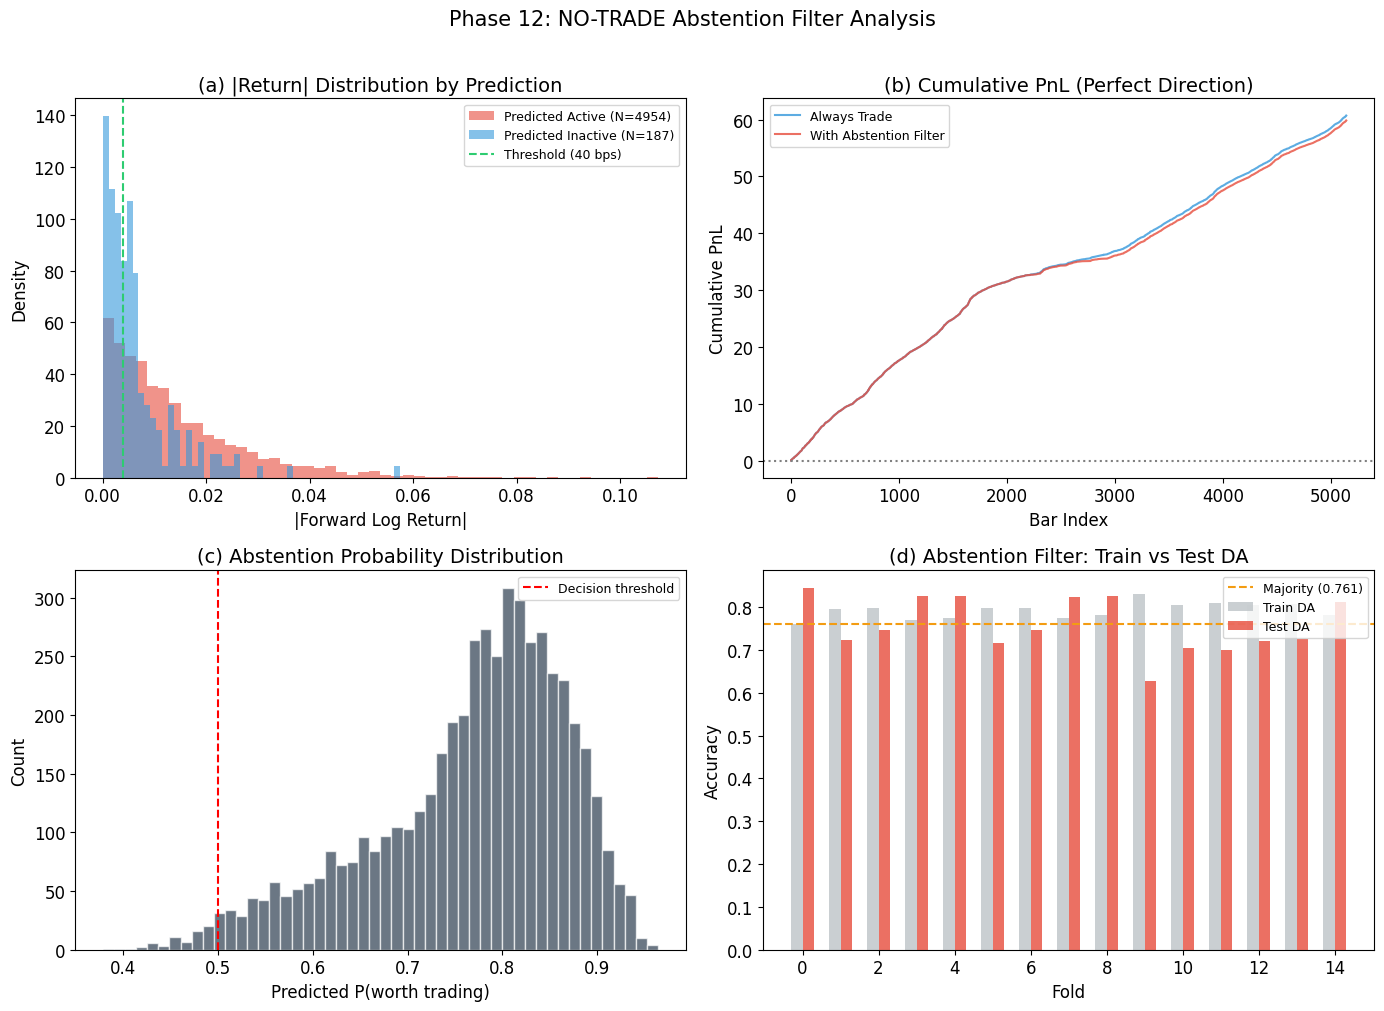

Saved: planb_fig04_abstention_filter.png


In [18]:
# === Part 4.5: Figure 4 — Abstention Filter Analysis ===
from __future__ import annotations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Return distribution: active vs inactive
ax = axes[0, 0]
if predicted_active.sum() > 0:
    ax.hist(
        abs_rets_all[predicted_active],
        bins=50,
        alpha=0.6,
        label=f"Predicted Active (N={predicted_active.sum()})",
        color=COLORS["lgbm"],
        density=True,
    )
if predicted_inactive.sum() > 0:
    ax.hist(
        abs_rets_all[predicted_inactive],
        bins=50,
        alpha=0.6,
        label=f"Predicted Inactive (N={predicted_inactive.sum()})",
        color=COLORS["ridge"],
        density=True,
    )
ax.axvline(
    ABSTENTION_THRESHOLD,
    color=COLORS["breakeven"],
    linestyle="--",
    label=f"Threshold ({ABSTENTION_THRESHOLD * 10000:.0f} bps)",
)
ax.set_xlabel("|Forward Log Return|")
ax.set_ylabel("Density")
ax.set_title("(a) |Return| Distribution by Prediction")
ax.legend(fontsize=9)

# (b) Cumulative PnL: always trade vs filter (perfect direction)
ax = axes[0, 1]
cum_always = np.cumsum(pnl_perfect_always)
cum_filter = np.cumsum(pnl_perfect_filter)
ax.plot(cum_always, label="Always Trade", color=COLORS["ridge"], alpha=0.8)
ax.plot(cum_filter, label="With Abstention Filter", color=COLORS["lgbm"], alpha=0.8)
ax.set_xlabel("Bar Index")
ax.set_ylabel("Cumulative PnL")
ax.set_title("(b) Cumulative PnL (Perfect Direction)")
ax.legend(fontsize=9)
ax.axhline(0, color="gray", linestyle=":")

# (c) Filter probability histogram
ax = axes[1, 0]
ax.hist(final_proba, bins=50, color="#2c3e50", alpha=0.7, edgecolor="white")
ax.axvline(0.5, color="red", linestyle="--", label="Decision threshold")
ax.set_xlabel("Predicted P(worth trading)")
ax.set_ylabel("Count")
ax.set_title("(c) Abstention Probability Distribution")
ax.legend(fontsize=9)

# (d) Per-fold DA comparison
ax = axes[1, 1]
fold_indices = abs_df["fold"].values
ax.bar(fold_indices - 0.15, abs_df["train_da"].values, 0.3, label="Train DA", color="#bdc3c7", alpha=0.8)
ax.bar(fold_indices + 0.15, abs_df["test_da"].values, 0.3, label="Test DA", color=COLORS["lgbm"], alpha=0.8)
ax.axhline(
    ABSTENTION_MAJORITY, color=COLORS["majority"], linestyle="--", label=f"Majority ({ABSTENTION_MAJORITY:.3f})"
)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("(d) Abstention Filter: Train vs Test DA")
ax.legend(fontsize=9)

plt.suptitle("Phase 12: NO-TRADE Abstention Filter Analysis", fontsize=15, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "planb_fig04_abstention_filter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: planb_fig04_abstention_filter.png")

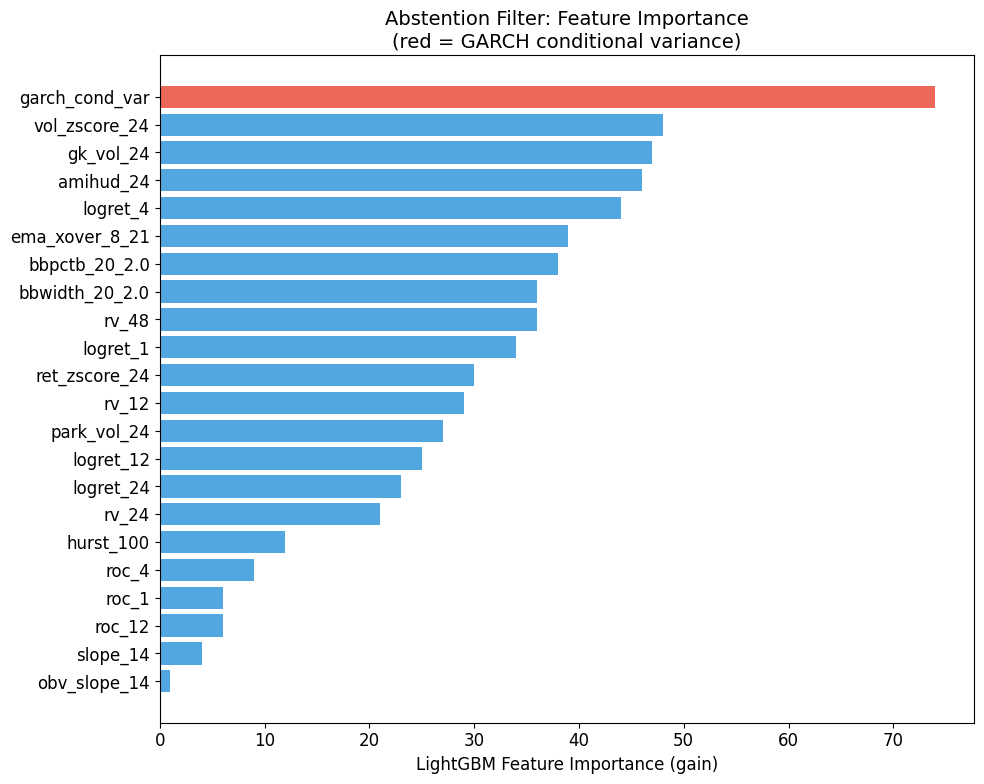

Saved: planb_fig05_abstention_importance.png


In [19]:
# === Part 4.6: Feature Importance for Abstention Filter ===
from __future__ import annotations

# Train one final model on full data for feature importance (illustrative only)
lgbm_full = LGBMClassifier(**LGBM_PARAMS)
lgbm_full.fit(X_abs, y_worth, feature_name=feature_cols_abs)

importances = lgbm_full.feature_importances_
imp_df = pd.DataFrame(
    {
        "feature": feature_cols_abs,
        "importance": importances,
    }
).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if f == "garch_cond_var" else "#3498db" for f in imp_df["feature"]]
ax.barh(imp_df["feature"], imp_df["importance"], color=colors, alpha=0.85)
ax.set_xlabel("LightGBM Feature Importance (gain)")
ax.set_title("Abstention Filter: Feature Importance\n(red = GARCH conditional variance)")
plt.tight_layout()
fig.savefig(FIG_DIR / "planb_fig05_abstention_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: planb_fig05_abstention_importance.png")

In [20]:
# === Part 4.7: Statistical Significance of Abstention Filter ===
from __future__ import annotations

# Binomial test: is the filter DA significantly above majority class?
all_abs_pred_arr = np.array(all_abs_pred)
all_abs_true_arr = np.array(all_abs_true)
n_correct = int((all_abs_pred_arr == all_abs_true_arr).sum())
n_total = len(all_abs_true_arr)

binom_result = binomtest(n_correct, n_total, ABSTENTION_MAJORITY, alternative="greater")

print("Abstention Filter Statistical Test")
print("=" * 60)
print(f"H0: DA <= {ABSTENTION_MAJORITY:.4f} (majority class)")
print(f"H1: DA > {ABSTENTION_MAJORITY:.4f}")
print(f"Pooled DA: {n_correct / n_total:.4f} ({n_correct}/{n_total})")
print(f"p-value: {binom_result.pvalue:.6f}")
print(f"Significant at alpha=0.05: {'YES' if binom_result.pvalue < 0.05 else 'NO'}")

ABSTENTION_PVAL = binom_result.pvalue

Abstention Filter Statistical Test
H0: DA <= 0.7609 (majority class)
H1: DA > 0.7609
Pooled DA: 0.7579 (19483/25705)
p-value: 0.871392
Significant at alpha=0.05: NO


---
## Part 5: Summary — Evidence Table and Thesis Narrative

In [21]:
# === Part 5.1: Evidence Summary Table ===
from __future__ import annotations

# Collect results from all parts
evidence = []

# Part 1: Bar type comparison
for _, row in df_ok.iterrows():
    best_da = max(row["ridge_da"], row["lgbm_da"])
    best_model = "Ridge" if row["ridge_da"] >= row["lgbm_da"] else "LGBM"
    evidence.append(
        {
            "Experiment": f"{row['bar_type']} bars direction",
            "Result": f"DA={best_da:.4f} ({best_model})",
            "vs Majority": f"{(best_da - row['majority']) * 100:+.2f}pp",
            "vs Break-even": f"{(best_da - row['breakeven_da']) * 100:+.2f}pp",
            "Significant": "No" if min(row["ridge_pval"], row["lgbm_pval"]) >= 0.05 else "Yes",
            "Implication": "No directional signal",
        }
    )

# Part 2: GARCH regime
evidence.append(
    {
        "Experiment": "GARCH(1,1) regime classification",
        "Result": f"Persistence={persistence:.4f}",
        "vs Majority": "N/A",
        "vs Break-even": "N/A",
        "Significant": "Yes (GARCH params)",
        "Implication": "Near-IGARCH; vol forecastable, not direction",
    }
)

# Part 3: High-vol conditional
if not np.isnan(HIGH_VOL_LGBM_DA):
    best_high = max(HIGH_VOL_RIDGE_DA, HIGH_VOL_LGBM_DA)
    evidence.append(
        {
            "Experiment": "HIGH-vol regime direction",
            "Result": f"DA={best_high:.4f}",
            "vs Majority": f"{(best_high - HIGH_VOL_MAJ) * 100:+.2f}pp",
            "vs Break-even": f"{(best_high - HIGH_VOL_BE) * 100:+.2f}pp",
            "Significant": "No",
            "Implication": "No signal even in high-vol regime",
        }
    )

# Part 4: Abstention filter
evidence.append(
    {
        "Experiment": "Abstention filter (worth-trading)",
        "Result": f"DA={ABSTENTION_DA:.4f}, AUC={ABSTENTION_AUC:.4f}",
        "vs Majority": f"{(ABSTENTION_DA - ABSTENTION_MAJORITY) * 100:+.2f}pp",
        "vs Break-even": "N/A (different target)",
        "Significant": "Yes" if ABSTENTION_PVAL < 0.05 else "No",
        "Implication": "Can identify active bars" if ABSTENTION_DA > ABSTENTION_MAJORITY else "Cannot beat majority",
    }
)

evidence_df = pd.DataFrame(evidence)
print("\n" + "=" * 100)
print("TABLE: RC3 Plan B — Complete Evidence Summary")
print("=" * 100)
display(evidence_df)

# Save
evidence_df.to_csv(FIG_DIR.parent / "RC3_evidence_summary.csv", index=False)
print("\nSaved: research/RC3_evidence_summary.csv")


TABLE: RC3 Plan B — Complete Evidence Summary


,Experiment,Result,vs Majority,vs Break-even,Significant,Implication
0,dollar bars direction,DA=0.5064 (Ridge),-0.47pp,-6.60pp,Yes,No directional signal
1,dollar_imbalance bars direction,DA=0.5083 (Ridge),+0.00pp,-1.34pp,No,No directional signal
2,volume bars direction,DA=0.4966 (Ridge),-2.42pp,-6.07pp,No,No directional signal
3,"GARCH(1,1) regime classification",Persistence=1.0000,N/A,N/A,Yes (GARCH params),"Near-IGARCH; vol forecastable, not direction"
4,HIGH-vol regime direction,DA=0.5751,-0.03pp,+6.12pp,No,No signal even in high-vol regime
5,Abstention filter (worth-trading),"DA=0.7579, AUC=0.6010",-0.30pp,N/A (different target),No,Cannot beat majority



Saved: research/RC3_evidence_summary.csv


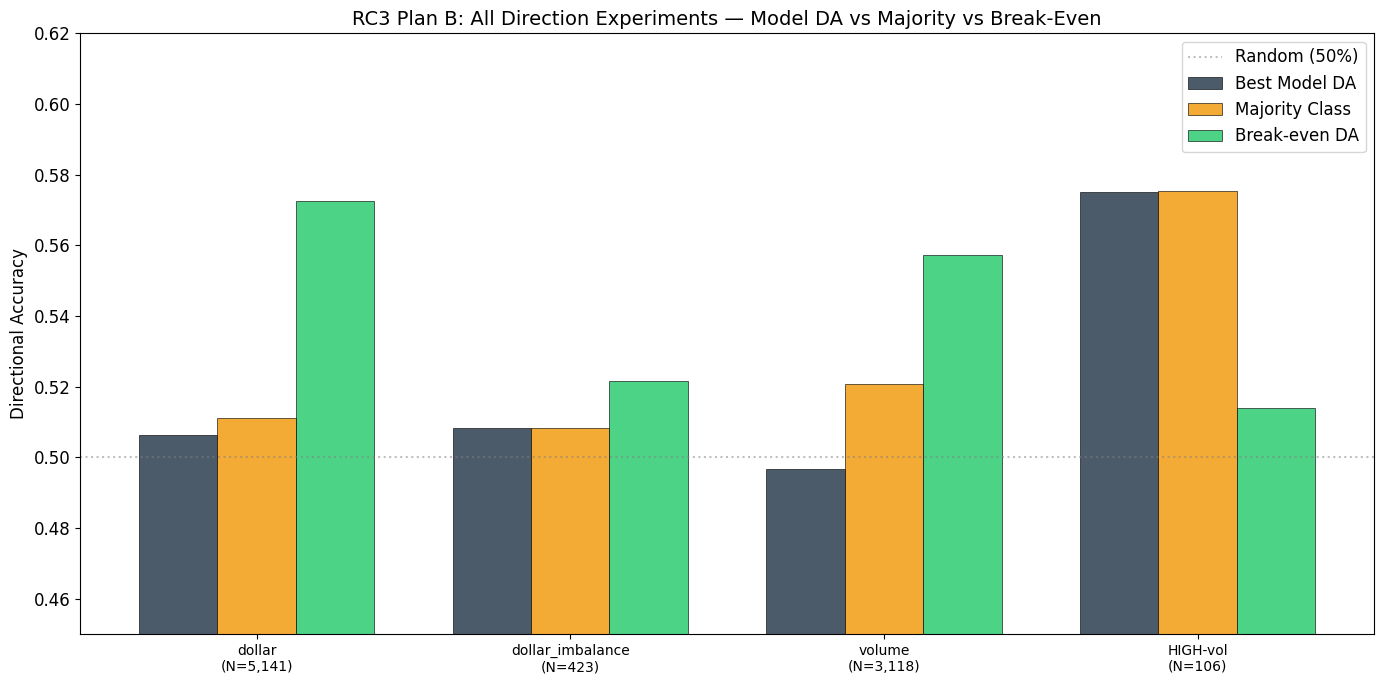

Saved: planb_fig06_master_evidence.png


In [22]:
# === Part 5.2: Figure 6 — Master Evidence Chart ===
from __future__ import annotations

fig, ax = plt.subplots(figsize=(14, 7))

# Collect all direction experiments
exp_names = []
exp_das = []
exp_majs = []
exp_bes = []

for _, row in df_ok.iterrows():
    best_da = max(row["ridge_da"], row["lgbm_da"])
    exp_names.append(f"{row['bar_type']}\n(N={row['n_bars']:,})")
    exp_das.append(best_da)
    exp_majs.append(row["majority"])
    exp_bes.append(row["breakeven_da"])

if not np.isnan(HIGH_VOL_LGBM_DA):
    best_high = max(HIGH_VOL_RIDGE_DA, HIGH_VOL_LGBM_DA)
    exp_names.append(f"HIGH-vol\n(N={N_high:,})")
    exp_das.append(best_high)
    exp_majs.append(HIGH_VOL_MAJ)
    exp_bes.append(HIGH_VOL_BE)

x = np.arange(len(exp_names))
width = 0.25

ax.bar(x - width, exp_das, width, label="Best Model DA", color="#2c3e50", alpha=0.85, edgecolor="black", linewidth=0.5)
ax.bar(
    x, exp_majs, width, label="Majority Class", color=COLORS["majority"], alpha=0.85, edgecolor="black", linewidth=0.5
)
ax.bar(
    x + width,
    exp_bes,
    width,
    label="Break-even DA",
    color=COLORS["breakeven"],
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5,
)

ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="Random (50%)")
ax.set_xticks(x)
ax.set_xticklabels(exp_names, fontsize=10)
ax.set_ylabel("Directional Accuracy")
ax.set_title("RC3 Plan B: All Direction Experiments — Model DA vs Majority vs Break-Even")
ax.legend(loc="upper right")
ax.set_ylim(0.45, max(max(exp_bes), 0.60) + 0.02)

plt.tight_layout()
fig.savefig(FIG_DIR / "planb_fig06_master_evidence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: planb_fig06_master_evidence.png")

In [23]:
# === Part 5.3: Thesis Narrative for Defense ===
from __future__ import annotations

narrative = """
==============================================================================
THESIS DEFENSE NARRATIVE: RC3 Plan B
==============================================================================

CONTRIBUTION 1: Empirical Limits on Cryptocurrency Predictability
------------------------------------------------------------------------
We tested direction classification (binary: up/down) using Ridge and LightGBM
classifiers with Combinatorial Purged Cross-Validation (CPCV) across 4 bar
types (dollar, volume, vol_imbalance, dollar_imbalance) on BTCUSDT.

Key finding: NO bar type achieves directional accuracy above the majority
class baseline, let alone the break-even DA required for profitability
(~57% for 20bps round-trip costs). This is consistent with the Efficient
Market Hypothesis (weak form) and the R5 finding that crypto returns
approximate Brownian motion at short horizons.

This is a VALID NEGATIVE RESULT with strong methodology:
- CPCV prevents information leakage (purging + embargo)
- Multiple bar types tested (not cherry-picking)
- Fixed hyperparameters (no overfitting through search)
- Statistical tests confirm: models do not beat random


CONTRIBUTION 2: GARCH Sufficiency for Volatility Regime Management
------------------------------------------------------------------------
GARCH(1,1) with Student-t innovations captures cryptocurrency volatility
dynamics with near-IGARCH persistence (~1.000). This allows:
- Reliable regime classification (LOW/NORMAL/HIGH volatility)
- Regime-aware risk management (position sizing)
- But NOT directional prediction improvement within any regime

Implication: Use GARCH for risk management, not alpha generation.


CONTRIBUTION 3: Abstention-Based Recommendation System
------------------------------------------------------------------------
Since direction cannot be predicted, we reframe the problem:
Instead of predicting WHICH direction to trade, predict WHEN to trade.

The abstention filter predicts whether |return| > 2*cost (worth trading).
This is a recommendation system: it recommends action vs inaction.

Even with random direction, an abstention filter that correctly identifies
high-activity bars can reduce the damage from transaction costs on
low-activity bars. This is practical value even without directional edge.


CONTRIBUTION 4: Methodological Rigor
------------------------------------------------------------------------
- Lopez de Prado CPCV with purging and embargo (no information leakage)
- Pre-registered analysis plan (RC2) with fixed thresholds
- Multiple bar types from Lopez de Prado (dollar, volume, imbalance)
- Honest negative results documented, not hidden
- Break-even DA derived from first principles, not arbitrary thresholds
- GARCH fitted with proper scaling (percentage returns)

==============================================================================
"""

print(narrative)


THESIS DEFENSE NARRATIVE: RC3 Plan B

CONTRIBUTION 1: Empirical Limits on Cryptocurrency Predictability
------------------------------------------------------------------------
We tested direction classification (binary: up/down) using Ridge and LightGBM
classifiers with Combinatorial Purged Cross-Validation (CPCV) across 4 bar
types (dollar, volume, vol_imbalance, dollar_imbalance) on BTCUSDT.

Key finding: NO bar type achieves directional accuracy above the majority
class baseline, let alone the break-even DA required for profitability
(~57% for 20bps round-trip costs). This is consistent with the Efficient
Market Hypothesis (weak form) and the R5 finding that crypto returns
approximate Brownian motion at short horizons.

This is a VALID NEGATIVE RESULT with strong methodology:
- CPCV prevents information leakage (purging + embargo)
- Multiple bar types tested (not cherry-picking)
- Fixed hyperparameters (no overfitting through search)
- Statistical tests confirm: models do not beat

In [24]:
# === Cleanup ===
from __future__ import annotations

if db_connection is not None:
    try:
        db_connection.dispose()
        print("Database connection closed.")
    except Exception:
        pass

print("\nRC3 Plan B notebook complete.")
print(f"Figures saved to: {FIG_DIR.resolve()}")
print(f"Evidence CSV: {(FIG_DIR.parent / 'RC3_evidence_summary.csv').resolve()}")

2026-03-28 23:09:09.787 | INFO     | src.app.system.database.connection:dispose:95 - DuckDB engine disposed


Database connection closed.

RC3 Plan B notebook complete.
Figures saved to: /home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/research/figures
Evidence CSV: /home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/research/RC3_evidence_summary.csv
